
ABACUS/VASP K-PATH ANALYZER - UPGRADED VERSION

📂 读取文件：J:\Sania\Structure\CuhisFeCN5NO\FM-1\STRU
✓ 已识别文件格式：STRU

------------------------------------------------------------
📊 结构基本信息
------------------------------------------------------------
化学式：Fe12 C57 N65 O13 Cu12 H8
晶胞参数 (Å)：a=28.056353, b=28.056353, c=47.357804
晶胞角度 (°)：α=90.0000, β=90.0000, γ=94.6812
原子数：167

------------------------------------------------------------
🎯 推荐SCF k点网格
------------------------------------------------------------
Monkhorst-Pack: 1 × 1 × 1

------------------------------------------------------------
🔍 高对称k点和能带路径 (seekpath)
------------------------------------------------------------
高对称点坐标（分数坐标）：
  GAMMA    : (0.000000, 0.000000, 0.000000)
  R_2      : (-0.500000, -0.500000, 0.500000)
  T_2      : (0.000000, -0.500000, 0.500000)
  U_2      : (-0.500000, 0.000000, 0.500000)
  V_2      : (0.500000, -0.500000, 0.000000)
  X        : (0.500000, 0.000000, 0.000000)
  Y        : (0.000000, 0.500000, 0.00

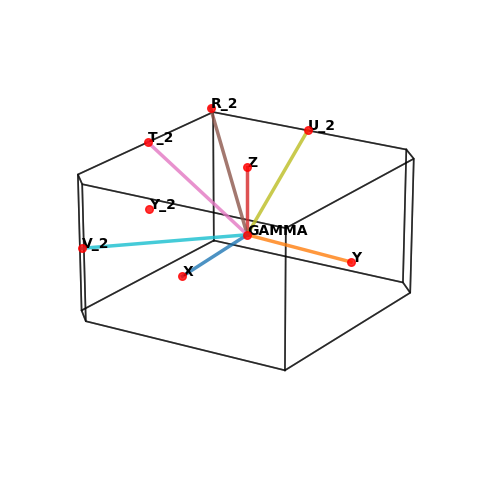


------------------------------------------------------------
💾 保存k点信息
------------------------------------------------------------
✓ 已保存k点信息：J:\Sania\Structure\CuhisFeCN5NO\FM-1\kpath_info.txt
✓ 已保存k点信息：J:\Sania\Structure\CuhisFeCN5NO\FM-1\kpath_info.json

✅ 分析完成！

📁 输出文件位置：J:\Sania\Structure\CuhisFeCN5NO\FM-1
   - brillouin_zone.png (布里渊区图)
   - kpath_info.txt (k点信息)
   - kpath_info.json (k点信息 JSON格式)


In [6]:
import os
import numpy as np

from pymatgen.core import Structure, Lattice
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.symmetry.bandstructure import HighSymmKpath
from pymatgen.electronic_structure.plotter import plot_brillouin_zone
from pymatgen.io.vasp.inputs import Kpoints

from ase.io import read
from seekpath import get_path


# ========= 自动文件类型识别 =========
def detect_file_type(filename):
    """自动识别文件格式（CIF, POSCAR, STRU）"""
    filename_upper = os.path.basename(filename).upper()
    
    # 根据文件名扩展名
    if filename_upper.endswith('.CIF'):
        return 'CIF'
    elif filename_upper == 'POSCAR' or filename_upper == 'CONTCAR':
        return 'POSCAR'
    elif filename_upper == 'STRU':
        return 'STRU'
    
    # 如果没有明确扩展名，尝试读取文件内容
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            first_lines = f.read(500)
        
        # 检查STRU格式特征
        if 'LATTICE_CONSTANT' in first_lines.upper() or 'ATOMIC_POSITIONS' in first_lines.upper():
            return 'STRU'
        # 检查CIF格式特征
        elif 'data_' in first_lines or '_cell_length_a' in first_lines:
            return 'CIF'
        # 检查POSCAR格式特征（通常是原子数字或原子符号）
        elif any(char.isdigit() for char in first_lines.split('\n')[1:4]):
            return 'POSCAR'
    except:
        pass
    
    # 默认尝试POSCAR
    return 'POSCAR'


# ========= 自定义 ABACUS STRU 解析器 =========
def read_abacus_stru(filename):
    """
    极简、稳健的 ABACUS STRU 解析器
    只读取：
      - LATTICE_CONSTANT
      - LATTICE_VECTORS
      - ATOMIC_POSITIONS (Direct / Cartesian)
    """
    with open(filename, "r", encoding="utf-8") as f:
        lines = [l.strip() for l in f if l.strip() and not l.strip().startswith("#")]

    # ---- lattice constant ----
    lat_const = 1.0
    for i, l in enumerate(lines):
        if l.upper() == "LATTICE_CONSTANT":
            lat_const = float(lines[i + 1].split()[0])
            break

    # ---- lattice vectors ----
    for i, l in enumerate(lines):
        if l.upper() == "LATTICE_VECTORS":
            lv = []
            for j in range(3):
                lv.append([float(x) for x in lines[i + 1 + j].split()[:3]])
            lattice = Lattice(np.array(lv) * lat_const)
            break
    else:
        raise RuntimeError("STRU 中未找到 LATTICE_VECTORS")

    # ---- atomic positions ----
    for i, l in enumerate(lines):
        if l.upper() == "ATOMIC_POSITIONS":
            mode = lines[i + 1].lower()   # direct / cartesian
            ptr = i + 2
            break
    else:
        raise RuntimeError("STRU 中未找到 ATOMIC_POSITIONS")

    species = []
    coords = []

    while ptr < len(lines):
        line = lines[ptr]
        parts = line.split()
        
        # 跳过空行
        if len(parts) == 0:
            ptr += 1
            continue
        
        # 检查是否是关键字（结束标志）
        if parts[0].upper() in {
            "NUMERICAL_ORBITAL", "ATOMIC_SPECIES",
            "K_POINTS", "NUMERICAL_DESCRIPTOR", "LATTICE_CONSTANT",
            "LATTICE_VECTORS"
        }:
            break
        
        # 尝试判断是否是坐标行（第一个字段可转换为浮点数）
        try:
            float(parts[0])
            ptr += 1
            continue
        except ValueError:
            pass
        
        # 这应该是元素符号行
        sym = parts[0]
        ptr += 1
        
        # 跳过空行
        while ptr < len(lines) and not lines[ptr].split():
            ptr += 1
        
        if ptr >= len(lines):
            break
        
        # 下一行是磁矩设置（0.000 或其他），跳过
        mag_line = lines[ptr].split()
        try:
            mag_val = float(mag_line[0])
            if len(mag_line) == 1 and mag_val < 100:
                ptr += 1
                while ptr < len(lines) and not lines[ptr].split():
                    ptr += 1
        except:
            pass
        
        if ptr >= len(lines):
            break
        
        # 现在应该是原子数量
        try:
            n = int(float(lines[ptr].split()[0]))
        except:
            ptr += 1
            continue
        
        ptr += 1
        
        # 读取 n 个原子坐标
        for _ in range(n):
            while ptr < len(lines) and not lines[ptr].split():
                ptr += 1
            
            if ptr >= len(lines):
                break
            
            xyz_parts = lines[ptr].split()
            if len(xyz_parts) >= 3:
                xyz = [float(xyz_parts[0]), float(xyz_parts[1]), float(xyz_parts[2])]
                species.append(sym)
                coords.append(xyz)
            ptr += 1

    if len(coords) == 0:
        raise RuntimeError("STRU 中未找到任何原子坐标")

    coords = np.array(coords)

    if mode.startswith("direct"):
        return Structure(lattice, species, coords, coords_are_cartesian=False)
    else:
        return Structure(lattice, species, coords, coords_are_cartesian=True)


# ========= 1. 通用读取结构函数 =========
def read_structure(filename):
    """
    自动识别文件格式并读取结构
    支持：CIF / POSCAR / STRU（ABACUS）
    """
    file_type = detect_file_type(filename)
    print(f"✓ 已识别文件格式：{file_type}")
    
    if file_type == 'STRU':
        return read_abacus_stru(filename)
    elif file_type == 'CIF':
        return Structure.from_file(filename)
    else:  # POSCAR
        return Structure.from_file(filename)


# ========= 2. seekpath 高对称路径 =========
def get_seekpath_kpath(structure):
    """计算seekpath高对称k点路径"""
    lattice = structure.lattice.matrix
    positions = [site.frac_coords for site in structure]
    numbers = [site.specie.number for site in structure]
    return get_path((lattice, positions, numbers))


# ========= 3. SCF 推荐 k 点（MOF 友好） =========
def recommend_kmesh(structure, L0=25.0):
    """推荐SCF k点网格"""
    a, b, c = structure.lattice.abc
    ka = max(1, int(np.ceil(L0 / a)))
    kb = max(1, int(np.ceil(L0 / b)))
    kc = max(1, int(np.ceil(L0 / c)))
    return ka, kb, kc


# ========= 4. 辅助函数：分数坐标转笛卡尔坐标 =========
def frac_k_to_cart(structure, k_frac):
    """seekpath 给的是 reciprocal basis 分数坐标 -> 转成倒空间笛卡尔坐标"""
    return structure.lattice.reciprocal_lattice.get_cartesian_coords(k_frac)


# ========= 5. 辅助函数：手动绘制布里渊区 =========
def plot_bz_manual(structure, sp, out="brillouin_zone.png", dpi=300):
    """绘制布里渊区并显示高对称k点和路径"""
    import matplotlib.pyplot as plt

    # 1) 取真正的 BZ 多面体（Wigner–Seitz cell in reciprocal space）
    bz_faces = structure.lattice.reciprocal_lattice.get_wigner_seitz_cell()
    bz_vertices = np.vstack([np.array(face) for face in bz_faces])

    # 2) 创建紧凑画布
    fig = plt.figure(figsize=(6.2, 6.0))
    ax = fig.add_subplot(111, projection="3d")

    # 3) 画 BZ 边
    for face in bz_faces:
        face = np.array(face)
        face_closed = np.vstack([face, face[0]])
        ax.plot(face_closed[:, 0], face_closed[:, 1], face_closed[:, 2], linewidth=1.2, color='black', alpha=0.6)

    # 4) 画高对称点
    k_cart = {}
    for label, kf in sp["point_coords"].items():
        kc = frac_k_to_cart(structure, kf)
        k_cart[label] = kc
        ax.scatter(kc[0], kc[1], kc[2], s=30, color='red', alpha=0.8)
        ax.text(kc[0], kc[1], kc[2], label, fontsize=10, fontweight='bold')

    # 5) 画路径线段
    colors = plt.cm.tab10(np.linspace(0, 1, len(sp["path"])))
    for idx, seg in enumerate(sp["path"]):
        pts = np.array([k_cart[p] for p in seg])
        ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], linewidth=2.5, color=colors[idx], alpha=0.8)

    # 6) 设定坐标轴范围
    xmin, ymin, zmin = bz_vertices.min(axis=0)
    xmax, ymax, zmax = bz_vertices.max(axis=0)
    xc, yc, zc = (xmin + xmax)/2, (ymin + ymax)/2, (zmin + zmax)/2
    half = max(xmax-xmin, ymax-ymin, zmax-zmin) * 0.52
    ax.set_xlim(xc - half, xc + half)
    ax.set_ylim(yc - half, yc + half)
    ax.set_zlim(zc - half, zc + half)
    ax.set_box_aspect([1, 1, 1])

    # 7) 视角与外观
    ax.view_init(elev=22, azim=35)
    ax.set_axis_off()

    # 保存和显示
    fig.savefig(out, dpi=dpi, bbox_inches="tight", pad_inches=0.02, facecolor="white")
    print(f"✓ 已保存布里渊区图：{out}")
    plt.show()


# ========= 6. 保存k点信息到文件 =========
def save_kpath_info(structure, sp, filename, format='txt'):
    """保存k点路径信息到文件"""
    import json
    
    if format == 'txt':
        with open(filename, 'w', encoding='utf-8') as f:
            f.write("=" * 60 + "\n")
            f.write("HIGH-SYMMETRY K-PATH INFORMATION\n")
            f.write("=" * 60 + "\n\n")
            
            f.write(f"Structure: {structure.composition}\n")
            f.write(f"Lattice parameters (Å): a={structure.lattice.a:.4f}, b={structure.lattice.b:.4f}, c={structure.lattice.c:.4f}\n")
            f.write(f"Lattice angles (°): α={structure.lattice.alpha:.2f}, β={structure.lattice.beta:.2f}, γ={structure.lattice.gamma:.2f}\n\n")
            
            f.write("High-Symmetry Points (fractional coordinates):\n")
            f.write("-" * 60 + "\n")
            for label, kf in sp["point_coords"].items():
                f.write(f"{label:8s} : {kf[0]:10.6f} {kf[1]:10.6f} {kf[2]:10.6f}\n")
            
            f.write("\nRecommended Band Path:\n")
            f.write("-" * 60 + "\n")
            for seg in sp["path"]:
                f.write("  " + " → ".join(seg) + "\n")
    
    elif format == 'json':
        data = {
            'composition': str(structure.composition),
            'lattice': {
                'a': float(structure.lattice.a),
                'b': float(structure.lattice.b),
                'c': float(structure.lattice.c),
                'alpha': float(structure.lattice.alpha),
                'beta': float(structure.lattice.beta),
                'gamma': float(structure.lattice.gamma),
            },
            'high_symmetry_points': {label: list(kf) for label, kf in sp["point_coords"].items()},
            'band_path': sp["path"]
        }
        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2)

    
    print(f"✓ 已保存k点信息：{filename}")


# ========= 7. 主程序（大升级版） =========
def analyze_structure(filename, output_dir=None, L0=25.0):
    """
    全功能结构分析程序
    
    参数：
    - filename: 结构文件路径（支持 CIF, POSCAR, STRU）
    - output_dir: 输出目录（默认为当前目录）
    - L0: k点网格参数（默认25 Å）
    """
    
    if output_dir is None:
        output_dir = os.path.dirname(filename) or '.'
    
    # 确保输出目录存在
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*60)
    print("ABACUS/VASP K-PATH ANALYZER - UPGRADED VERSION")
    print("="*60)
    
    # 读取结构
    print(f"\n📂 读取文件：{filename}")
    try:
        s = read_structure(filename)
    except Exception as e:
        print(f"❌ 读取文件失败：{e}")
        return None
    
    # 基本信息
    print("\n" + "-"*60)
    print("📊 结构基本信息")
    print("-"*60)
    print(f"化学式：{s.composition}")
    print(f"晶胞参数 (Å)：a={s.lattice.a:.6f}, b={s.lattice.b:.6f}, c={s.lattice.c:.6f}")
    print(f"晶胞角度 (°)：α={s.lattice.alpha:.4f}, β={s.lattice.beta:.4f}, γ={s.lattice.gamma:.4f}")
    print(f"原子数：{len(s)}")
    
    # SCF k点推荐
    ka, kb, kc = recommend_kmesh(s, L0=L0)
    print("\n" + "-"*60)
    print("🎯 推荐SCF k点网格")
    print("-"*60)
    print(f"Monkhorst-Pack: {ka} × {kb} × {kc}")
    
    # seekpath高对称路径
    print("\n" + "-"*60)
    print("🔍 高对称k点和能带路径 (seekpath)")
    print("-"*60)
    sp = get_seekpath_kpath(s)
    
    print("高对称点坐标（分数坐标）：")
    for k, v in sorted(sp["point_coords"].items()):
        print(f"  {k:8s} : ({v[0]:8.6f}, {v[1]:8.6f}, {v[2]:8.6f})")
    
    print("\n推荐能带路径：")
    for idx, seg in enumerate(sp["path"], 1):
        print(f"  第{idx}段：{' → '.join(seg)}")
    
    # HighSymmKpath尝试
    print("\n" + "-"*60)
    print("🔍 高对称k点和能带路径 (HighSymmKpath - 备选)")
    print("-"*60)
    try:
        kpath = HighSymmKpath(s)
        print("路径：")
        for seg in kpath.kpath["path"]:
            print(f"  {' → '.join(seg)}")
    except Exception as e:
        print(f"⚠️  HighSymmKpath 失败（对复杂或磁性结构正常）：{type(e).__name__}")
    
    # 绘制布里渊区
    print("\n" + "-"*60)
    print("📈 绘制布里渊区图")
    print("-"*60)
    bz_file = os.path.join(output_dir, "brillouin_zone.png")
    plot_bz_manual(s, sp, out=bz_file, dpi=300)
    
    # 保存k点信息
    print("\n" + "-"*60)
    print("💾 保存k点信息")
    print("-"*60)
    txt_file = os.path.join(output_dir, "kpath_info.txt")
    json_file = os.path.join(output_dir, "kpath_info.json")
    save_kpath_info(s, sp, txt_file, format='txt')
    save_kpath_info(s, sp, json_file, format='json')
    
    print("\n" + "="*60)
    print("✅ 分析完成！")
    print("="*60)
    print(f"\n📁 输出文件位置：{output_dir}")
    print(f"   - brillouin_zone.png (布里渊区图)")
    print(f"   - kpath_info.txt (k点信息)")
    print(f"   - kpath_info.json (k点信息 JSON格式)")
    
    return s, sp


# ========= 8. 命令行使用示例 =========
if __name__ == "__main__":
    # 例子：分析STRU文件
    struct_file = r"J:\Sania\Structure\CuhisFeCN5NO\FM-1\STRU"
    
    # 自动识别文件格式，分析结构，保存结果
    s, sp = analyze_structure(struct_file, output_dir=None, L0=25.0)